In [1]:
import pandas as pd

In [4]:
delays = pd.read_excel("ttc-streetcar-delay-data-2024.xlsx")

In [5]:
delays.head()


,Date,Line,Time,Day,Location,Incident,Min Delay,Min Gap,Bound,Vehicle
0,2024-01-01,505,02:45,Monday,DUNDAS AND MCCAUL,Security,10,20,W,4416
1,2024-01-01,505,03:06,Monday,COLLEGE AND GLADSTONE,Emergency Services,52,72,E,4461
2,2024-01-01,503,03:21,Monday,PARLIAMENT AND SHUTTER,Security,0,0,N,4545
3,2024-01-01,505,03:53,Monday,DUNDAS WEST STATION,Security,37,0,W,4551
4,2024-01-01,600,04:27,Monday,QUEEN AND BATHURST,Diversion,78,93,E,8116


In [8]:
import pandas as pd
import numpy as np

# Example data
df = delays

# Convert to datetime (no date part, just time)
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

# Extract hour and minute
df['hour'] = df['Time'].dt.hour
df['minute'] = df['Time'].dt.minute

# Convert time to a fraction of a full 24-hour day
df['time_ratio'] = (df['hour'] * 60 + df['minute']) / (24 * 60)

# Create sin and cos encoding
df['sin_time'] = np.sin(2 * np.pi * df['time_ratio'])
df['cos_time'] = np.cos(2 * np.pi * df['time_ratio'])

# View the result
df.head()

,Date,Line,Time,Day,Location,Incident,Min Delay,Min Gap,Bound,Vehicle,hour,minute,time_ratio,sin_time,cos_time
0,2024-01-01,505,1900-01-01 02:45:00,Monday,DUNDAS AND MCCAUL,Security,10,20,W,4416,2,45,0.114583,0.659346,0.751840
1,2024-01-01,505,1900-01-01 03:06:00,Monday,COLLEGE AND GLADSTONE,Emergency Services,52,72,E,4461,3,6,0.129167,0.725374,0.688355
2,2024-01-01,503,1900-01-01 03:21:00,Monday,PARLIAMENT AND SHUTTER,Security,0,0,N,4545,3,21,0.139583,0.768842,0.639439
3,2024-01-01,505,1900-01-01 03:53:00,Monday,DUNDAS WEST STATION,Security,37,0,W,4551,3,53,0.161806,0.850352,0.526214
4,2024-01-01,600,1900-01-01 04:27:00,Monday,QUEEN AND BATHURST,Diversion,78,93,E,8116,4,27,0.185417,0.918791,0.394744


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df[['sin_time', 'cos_time']]
y = df['Min Delay']

# Train linear regression
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Evaluate
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R²:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

Coefficients: [1.29690614 0.8975114 ]
Intercept: 16.204641129808223
R²: 0.000991151099588139
RMSE: 34.92584464792486


<Axes: xlabel='hour'>

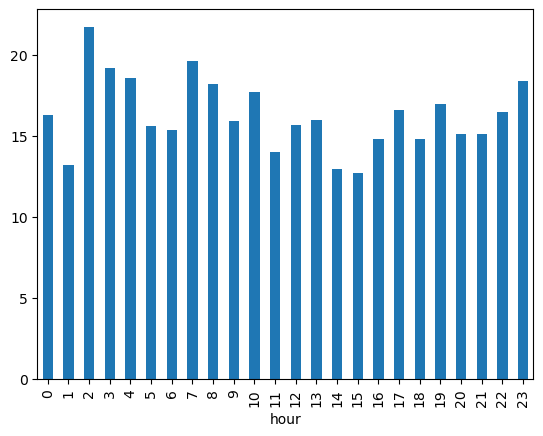

In [12]:
df['hour'] = df['Time'].dt.hour
df.groupby('hour')['Min Delay'].mean().plot(kind='bar')